# Matching

The purpose of this file is to do one set of matching: **treatment matching**, to match those who graduated from the program against those that did not graduate from the program. 

We will match to examine the following:

-Graduation effect for **earnings** (income)

-Graduation effect for **employment**

-Graduation effect for **criminal justice interaction** (as measured by arrests)

-Graduation effect for **recidivism** (as measured by offenses)

This will be followed (in future analysis) by intent to treat matching of TIP participants with similar non-participants, which we expect will be particularly relevant for criminal justice and recidivism outcomes. 


# Preparation

In [582]:
#Import necessary packages

import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import tqdm
##!pip install linearmodels
from linearmodels import PanelOLS
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable

In [583]:
#Import necessary files

#Student datafile, data up to December 2025 
tip_clean = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\TIP_clean.csv', parse_dates=['CreatedDate','DoB', 'Interviewed Only Date', 'InterviewedDate','StartDate','EndDate'])

#Demographic datafile, data up to December 2024
tip_demos = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\tip_cohort_demographics_rg.csv')

#Sentencing datafile, data up to December 2024
tip_sentencing = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\convictions_matched_to_tip_final.csv', parse_dates = ['DOB', 'GraduatedDate', 'InterviewedDate', 'StartDate','EndDate', 'DOF', 'DOS'])

#Arrests datafile, data up to December 2024
tip_arrests = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\arrest_data.csv', parse_dates = ['CaseFiledDate', 'ArrestDate', 'DefendantDOB', 'OffenseDate','OffenseDispositionDate','CaseDispositionDate','InterviewedDate','Orientation Date', 'GraduatedDate', 'CreatedDate','StartDate','EndDate'])


#Earnings datafile, data up to December 2024
tip_earnings = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\tip_cohort_uiearnings.csv')

#Deflation information to deflate earnings data
df_inflation = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\inflation_data.csv')



C:\Users\sarah\AppData\Local\Temp\ipykernel_26960\2056106457.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tip_arrests = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\arrest_data.csv', parse_dates = ['CaseFiledDate', 'ArrestDate', 'DefendantDOB', 'OffenseDate','OffenseDispositionDate','CaseDispositionDate','InterviewedDate','Orientation Date', 'GraduatedDate', 'CreatedDate','StartDate','EndDate'])
C:\Users\sarah\AppData\Local\Temp\ipykernel_26960\2056106457.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tip_arrests = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\arrest_data.csv', parse_dates = ['CaseFiledDat

In [584]:
#Clean student datafile column names

all_tip_students = tip_clean.rename(columns={
    'participant_id' : 'tip_id',
    'DoB' : 'DOB',
    'Status' : 'tip_status',
})

#Define statuses as "Graduated" or "Non Graduated" - for the purposes of this matched analysis, we do not care about individuals who do not fall into these statuses

def status(row):
    ts = str(row['tip_status'])
    if "Graduate" in ts:
        return 'Graduated'
    #TIP does not consider individuals who did not finish orientation to be participants, so all DNF status EXCEPT those that are DNF orientation are our "Non Graduated" pool
    elif ("DNF" in ts) and ("Orientation" not in ts):
        return 'Non Graduated'
    else:
        return 'None'

all_tip_students['Status'] = all_tip_students.apply(status, axis=1)
all_tip_students.Status.value_counts()

Status
None             1281
Graduated         893
Non Graduated     549
Name: count, dtype: int64

In [585]:
all_tip_students.columns

Index(['tip_id', 'CreatedDate', 'DOB', 'tip_status', 'Course', 'StartDate',
       'EndDate', 'InterviewedDate', 'Interviewed Only Date', 'DriversLicense',
       'EndDriversLicense', 'AccessBank', 'EndBank', 'EndComputer',
       'AccessComputer', 'AccessHealthInsurance', 'EndHealthInsurance',
       'AccessInternet', 'EndInternet', 'AccessResume', 'EndResume',
       'License To Thrive', 'Workforce Housing', 'SNAP Assistance',
       'Age_at_start', 'Status'],
      dtype='object')

In [586]:
#Put together our cleaned student data frame (which we will call df_student)

df_student = all_tip_students.copy()

date_cols = ['DOB', 'StartDate', 'EndDate', 'InterviewedDate', 'Interviewed Only Date']
for col in date_cols:
    if col in df_student.columns:
        df_student[col] = pd.to_datetime(df_student[col], errors = 'coerce')

##Add an indicator for cohort based on StartDate
cutoff = pd.Timestamp("2022-01-01")
df_student["cohort_2022"] = np.where(
    df_student["StartDate"].notna(),
    np.where(df_student["StartDate"] >= cutoff, 1, 0),
    np.nan
)

df_student["cohort_2022"] = pd.to_numeric(df_student["cohort_2022"], errors = "coerce")

#Drop anyone with nonsensical ages (under 16)
df_student = df_student[df_student['Age_at_start'] >= 16]

#Add age band based on age at start

def assign_age_band(age):
    if pd.isna(age):
        return np.nan
    elif 18 <= age <= 24:
        return '<=24'
    elif 25 <= age <= 34:
        return '25-34'
    elif age >= 35:
        return '35+'
    else:
        return np.nan

df_student['age_band'] = df_student['Age_at_start'].apply(assign_age_band)

df_student.head()

,tip_id,CreatedDate,DOB,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,...,EndInternet,AccessResume,EndResume,License To Thrive,Workforce Housing,SNAP Assistance,Age_at_start,Status,cohort_2022,age_band
0,1,2018-07-11 00:00:00+00:00,1992-08-26,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01 00:00:00+00:00,NaT,NaT,No,...,NaN,NaN,NaN,NaN,NaN,NaN,25.840055,Non Graduated,0.0,25-34
1,2,2018-07-11 00:00:00+00:00,1997-01-27,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,...,NaN,NaN,NaN,NaN,NaN,NaN,21.424470,Non Graduated,0.0,<=24
2,3,2018-07-11 00:00:00+00:00,1999-05-04,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,19.193438,Non Graduated,0.0,<=24
3,4,2018-07-12 00:00:00+00:00,1982-08-15,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16 00:00:00+00:00,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,30.950103,Graduated,0.0,25-34
4,5,2018-07-12 00:00:00+00:00,1988-04-10,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04 00:00:00+00:00,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,22.605605,Graduated,0.0,<=24


In [587]:
#Merge with demographics

tip_demos['tip_id'] = pd.to_numeric(tip_demos['tip_id'], errors='coerce')
df_student['tip_id'] = pd.to_numeric(df_student['tip_id'], errors='coerce')

df_student = df_student.merge(
    tip_demos,
    on = 'tip_id',
    how = 'left'
)

In [588]:
#Prepare sentencing data

tip_sentencing['DOB'] = pd.to_datetime(tip_sentencing['DOB'], errors='coerce').dt.tz_localize(None)
tip_sentencing['StartDate'] = pd.to_datetime(tip_sentencing['StartDate'], errors='coerce').dt.tz_localize(None)
tip_sentencing['EndDate'] = pd.to_datetime(tip_sentencing['EndDate'], errors='coerce').dt.tz_localize(None)
tip_sentencing['tip_id'] = pd.to_numeric(tip_sentencing['tip_id'], errors='coerce')
tip_sentencing['age_at_sentencing'] = (
    (tip_sentencing['DOS'] - tip_sentencing['DOB'])).dt.days // 365

# merge student StartDate for consistent baseline cutoff
tip_sentencing = tip_sentencing.merge(
    df_student[['tip_id', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_sentencing.columns:
    tip_sentencing['StartDate'] = tip_sentencing['StartDate_student'].combine_first(tip_sentencing['StartDate'])
    tip_sentencing = tip_sentencing.drop(columns=['StartDate_student'])

# before TIP start
sent_before = tip_sentencing[
    tip_sentencing['DOS'].notna() &
    tip_sentencing['StartDate'].notna() &
    (tip_sentencing['DOS'] < tip_sentencing['StartDate'])
].copy()

sent_summary = sent_before.groupby('tip_id').agg(
    num_sentences_before_start=('DOS', 'count'),
    any_sentence_before_start=('DOS', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_sentencing_before_start=('age_at_sentencing', 'min'),
    max_ogs_before_start=('OGS', 'max'),
    any_high_ogs_before_start=('OGS', lambda x: 1 if (x > 5).any() else 0)
).reset_index()

#create wide table
sent_wide= tip_sentencing[['tip_id', 'age_at_sentencing']].drop_duplicates()
sent_wide['value'] = 1
sent_wide = sent_wide.pivot(index='tip_id', columns='age_at_sentencing', values='value').fillna(0)
sent_wide = sent_wide.reset_index().rename_axis(None, axis=1)

drop_cols = [np.nan]
for column in sent_wide.columns[2:]:
    column = int(column)
    new_col = f'{column}_sentencing_age'
    sent_wide[new_col] = sent_wide[column]
    drop_cols.append(column)

sent_wide = sent_wide.drop(columns=drop_cols)

#create a high OGS table
high_tip_ogs = tip_sentencing[tip_sentencing['OGS'] > 5]
high_tip_ogs_wide = high_tip_ogs[['tip_id', 'age_at_sentencing']].drop_duplicates().dropna()
high_tip_ogs_wide['value'] = 1
high_tip_ogs_wide = high_tip_ogs_wide.pivot(index='tip_id', columns='age_at_sentencing', values='value').fillna(0)
high_tip_ogs_wide = high_tip_ogs_wide.reset_index().rename_axis(None, axis=1)

drop_cols = []
for column in high_tip_ogs_wide.columns[1:]:
    column = int(column)
    new_col = f'{column}_sentencing_age_high_ogs'
    high_tip_ogs_wide[new_col] = high_tip_ogs_wide[column]
    drop_cols.append(column)

high_tip_ogs_wide = high_tip_ogs_wide.drop(columns=drop_cols)

#Merge both wide tables together
sent_wide = sent_wide.merge(
    high_tip_ogs_wide, 
    on='tip_id', 
    how='left').fillna(0)

sent_wide.head()

,tip_id,16_sentencing_age,17_sentencing_age,18_sentencing_age,19_sentencing_age,20_sentencing_age,21_sentencing_age,22_sentencing_age,23_sentencing_age,24_sentencing_age,...,43_sentencing_age_high_ogs,44_sentencing_age_high_ogs,45_sentencing_age_high_ogs,46_sentencing_age_high_ogs,47_sentencing_age_high_ogs,48_sentencing_age_high_ogs,49_sentencing_age_high_ogs,51_sentencing_age_high_ogs,52_sentencing_age_high_ogs,58_sentencing_age_high_ogs
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [589]:
#Prepare arrests data (similar process to conviction data above)

tip_arrests['tip_id'] = pd.to_numeric(tip_arrests['tip_id'], errors='coerce')

tip_arrests = tip_arrests.merge(
    df_student[['tip_id', 'DOB', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_arrests.columns:
    tip_arrests['StartDate'] = tip_arrests['StartDate_student'].combine_first(tip_arrests['StartDate'])
    tip_arrests = tip_arrests.drop(columns=['StartDate_student'])

tip_arrests['age_at_arrest'] = (
    (tip_arrests['ArrestDate'] - tip_arrests['DOB']).dt.days // 365
)

arrests_before = tip_arrests[
    tip_arrests['ArrestDate'].notna() &
    tip_arrests['StartDate'].notna() &
    (tip_arrests['ArrestDate'] < tip_arrests['StartDate'])
].copy()

arrest_summary = arrests_before.groupby('tip_id').agg(
    num_arrests_before_start=('ArrestDate', 'count'),
    any_arrest_before_start=('ArrestDate', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_arrest_before_start=('age_at_arrest', 'min')
).reset_index()

#pivot wider
arrests_wide = tip_arrests[['tip_id', 'age_at_arrest']].drop_duplicates()
arrests_wide['value'] = 1
arrests_wide = arrests_wide.pivot(index='tip_id', columns='age_at_arrest', values='value').fillna(0).reset_index().rename_axis(None, axis=1)

drop_cols = [np.nan]
for column in arrests_wide.columns[2:]:
    column = int(column)
    new_col = f'{column}_arrest_age'
    arrests_wide[new_col] = arrests_wide[column]
    drop_cols.append(column)

arrests_wide = arrests_wide.drop(columns=drop_cols)

#add YearsSinceTIP to long df for later outcome analysis
tip_arrests['YearsSinceTIP'] = (tip_arrests['ArrestDate'] - tip_arrests['StartDate']).dt.days / 365


In [590]:
#Prepare earnings data

# process quarter to datetime
q_str = tip_earnings["quarter"].astype(str).str.strip()

tip_earnings["year"] = q_str.str[:4].astype(int)
tip_earnings["qnum"] = q_str.str[-1].astype(int)  # 1-4

# map to calendar quarter end month/day
# Q1 -> 03/31
# Q2 -> 06/30
# Q3 -> 09/30
# Q4 -> 12/31 

#Nikki: This was slightly different in your code. I matched it to what we did for the midterm analysis.
month_map = {1: 3, 2: 6, 3: 9, 4: 12}
day_map   = {1: 31, 2: 30, 3: 30, 4: 31}

tip_earnings["cal_end_year"] = tip_earnings["year"]
tip_earnings["cal_end_month"] = tip_earnings["qnum"].map(month_map)
tip_earnings["cal_end_day"] = tip_earnings["qnum"].map(day_map)

tip_earnings["year_quarter_dt"] = pd.to_datetime(
    dict(
        year=tip_earnings["cal_end_year"],
        month=tip_earnings["cal_end_month"],
        day=tip_earnings["cal_end_day"],
    ),
    errors="coerce",
)

tip_earnings["year_month"] = tip_earnings["year_quarter_dt"].dt.to_period("M")
tip_earnings.drop(columns=["Unnamed: 0", "qnum", "cal_end_year", "cal_end_month", "cal_end_day"], errors="ignore", inplace=True)

In [591]:
df_inflation.columns

Index(['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec', 'HALF1', 'HALF2'],
      dtype='object')

In [592]:
#Adjust earnings data for inflation (deflate the data)
df_inflation.drop(columns=['HALF1', 'HALF2'], inplace=True)
df_inflation = df_inflation.melt(id_vars='Year', var_name='Month', value_name='CPI')

month_map = {'Jan':'01','Feb':'02','Mar':'03','Apr':'04','May':'05','Jun':'06',
             'Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
df_inflation["year_month"] = (
    df_inflation["Year"].astype(str) + "-" + df_inflation["Month"].map(month_map)
)
# sort by date to ensure that the latest CPI value is at the end of the DataFrame
df_inflation = df_inflation.sort_values("year_month").reset_index(drop=True)
latest_cpi = df_inflation.loc[df_inflation["year_month"] == "2025-12", "CPI"].iloc[0]

tip_earnings["year_month"] = tip_earnings["year_month"].astype(str)

cpi_map = df_inflation.drop_duplicates("year_month").set_index("year_month")["CPI"]
tip_earnings["CPI"] = tip_earnings["year_month"].map(cpi_map)

tip_earnings["adjusted_earnings"] = tip_earnings["earnings"] * (latest_cpi / tip_earnings["CPI"])

In [593]:
tip_earnings.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,naics_industry_2022,year,year_quarter_dt,year_month,CPI,adjusted_earnings
0,655,20182,LEHIGH VALLEY RESTAURANT GROUP INC,1434,722511.0,Accommodation and food services,Food services and drinking places,Full-Service Restaurants,Accommodation and Food Services,Food Services and Drinking Places,Full-Service Restaurants,2018,2018-06-30,2018-06,251.989,1844.102068
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,4136.708548
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,6117.649056
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,2477.600167
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,9303.985951


In [594]:
#Calculate earnings 1 year and 2 years pre-TIP for match

tip_earnings = pd.merge(
    tip_earnings,
    df_student[['tip_id', 'StartDate']].drop_duplicates(),
    on='tip_id',
    how = 'left'
)
    
# keep non-missing earnings, but DO NOT drop zeros
tip_earnings = tip_earnings.dropna(subset=['earnings', 'StartDate']).copy()

# time distance relative to TIP start
tip_earnings['quarters_from_start'] = (
    (tip_earnings['year_quarter_dt'].dt.year - tip_earnings['StartDate'].dt.year) * 4
    + (tip_earnings['year_quarter_dt'].dt.quarter - tip_earnings['StartDate'].dt.quarter)
)

tip_earnings.head()

#aggregate 1-year pre-TIP earnings (quarters -1 through -4)
earnings_1yr_pre = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-4, -1)]
    .groupby('tip_id')['adjusted_earnings']
    .sum()
    .reset_index()
    .rename(columns={'adjusted_earnings': 'earnings_1yr_preTIP'})
)

#2-year pre-TIP earnings (quarters -5 through -8)
earnings_2yr_pre = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-8, -5)]
    .groupby('tip_id')['adjusted_earnings']
    .sum()
    .reset_index()
    .rename(columns={'adjusted_earnings': 'earnings_2yr_preTIP'})
)

earnings_2yr_pre.head()

,tip_id,earnings_2yr_preTIP
0,1,410.102835
1,2,8049.772420
2,29,35597.891193
3,210,3436.631229
4,216,1467.860077


In [595]:
#Summarize employment immediately pre-TIP using earnings data (just checks for existence of any earnings in the year immediately prior to TIP
job_right_before = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-4, -1)]  #Nikki I adjusted this to quarters 1-4 instead of just quarter 1
    .groupby('tip_id')['adjusted_earnings']
    .apply(lambda x: 1 if (x > 0).any() else 0)
    .reset_index(name='job_right_before_tip')
)

In [596]:
#Calculate age at point of each earnings record and pivot wide

tip_dob = df_student[['tip_id', 'DOB']].drop_duplicates()
tip_earnings = pd.merge(
    tip_earnings,
    tip_dob,
    on='tip_id',
    how='left'
)

tip_earnings['age'] = (tip_earnings['year_quarter_dt']-tip_earnings['DOB']).dt.days//365

#pivot wider
earnings_wide = tip_earnings[['tip_id','age', 'adjusted_earnings']].copy()
earnings_wide = earnings_wide.groupby(['tip_id', 'age'])['adjusted_earnings'].sum().reset_index()
earnings_wide = earnings_wide.pivot(index='tip_id', columns='age', values='adjusted_earnings').fillna(0)
earnings_wide = earnings_wide.reset_index().rename_axis(None, axis=1)
earnings_wide.rename(columns={col: f'{col}_earnings' for col in earnings_wide.columns[1:]}, inplace=True)

##TO DISCUSS: Some records are for individuals that were apparently 10-13 at the time of the earnings record. Maybe a mismatch?
earnings_wide.head()

#add YearsSinceTIP to long df for later outcome analysis
tip_earnings['YearsSinceTIP'] = (tip_earnings['year_quarter_dt'] - tip_earnings['StartDate']).dt.days / 365

In [597]:
tip_earnings[tip_earnings['age'] < 16][['tip_id', 'DOB', 'year_quarter_dt', 'adjusted_earnings', 'age']].head()

,tip_id,DOB,year_quarter_dt,adjusted_earnings,age
39,1292,2002-02-19,2017-12-31,1263.227491,15
40,1292,2002-02-19,2017-12-31,946.434749,15
50,1641,2002-10-11,2017-12-31,10437.072090,15
51,1641,2002-10-11,2017-12-31,1635.228927,15
52,2246,2002-03-17,2017-12-31,8294.448979,15


In [598]:
#Create one wide dataframe

all_tip_data = pd.merge(
    df_student,
    sent_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)

all_tip_data = pd.merge(
    all_tip_data,
    arrests_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)


In [599]:
#fill remaining NAs (for unmatched IDs) with 0s
all_tip_data[sent_wide.columns] = all_tip_data[sent_wide.columns].fillna(0)
all_tip_data[arrests_wide.columns] = all_tip_data[arrests_wide.columns].fillna(0)
all_tip_data[earnings_wide.columns] = all_tip_data[earnings_wide.columns].fillna(0)
all_tip_data[tip_demos.columns] = all_tip_data[tip_demos.columns].fillna(0)

all_tip_data.head()

,tip_id,CreatedDate,DOB,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,...,56_earnings,57_earnings,58_earnings,59_earnings,60_earnings,61_earnings,62_earnings,63_earnings,64_earnings,65_earnings
0,1,2018-07-11 00:00:00+00:00,1992-08-26,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01 00:00:00+00:00,NaT,NaT,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2018-07-11 00:00:00+00:00,1997-01-27,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2018-07-11 00:00:00+00:00,1999-05-04,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,2018-07-12 00:00:00+00:00,1982-08-15,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16 00:00:00+00:00,NaT,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,2018-07-12 00:00:00+00:00,1988-04-10,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04 00:00:00+00:00,NaT,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [600]:
#combine with summary data for matching
all_tip_data = pd.merge(
    all_tip_data,
    sent_summary, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    arrest_summary, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_1yr_pre, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_2yr_pre, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    job_right_before, 
    on='tip_id', 
    how='left'
)

tip_fill_zero_cols = [
    'num_sentences_before_start',
    'any_sentence_before_start',
    'max_ogs_before_start',
    'any_high_ogs_before_start',
    'num_arrests_before_start',
    'any_arrest_before_start',
    'earnings_1yr_preTIP',
    'earnings_2yr_preTIP',
    'job_right_before_tip'
]

for col in tip_fill_zero_cols:
    if col in all_tip_data.columns:
        all_tip_data[col] = all_tip_data[col].fillna(0)




In [601]:
print("all_tip_data shape:", all_tip_data.shape)
print("\nTIP missingness summary:")
print(
    all_tip_data[
        [
            'tip_id', 'DOB', 'StartDate', 'Status', 'cohort_2022',
            'Age_at_start', 'age_band', 'gender', 'race', 'census_tract',
            'num_sentences_before_start', 'any_sentence_before_start',
            'max_ogs_before_start', 'any_high_ogs_before_start',
            'num_arrests_before_start', 'any_arrest_before_start',
            'earnings_1yr_preTIP', 'earnings_2yr_preTIP',
            'job_right_before_tip'
        ]
    ].isna().sum()
)

all_tip_data shape: (1801, 228)

TIP missingness summary:
tip_id                          0
DOB                             0
StartDate                       0
Status                          0
cohort_2022                     0
Age_at_start                    0
age_band                      141
gender                          0
race                            0
census_tract                    0
num_sentences_before_start      0
any_sentence_before_start       0
max_ogs_before_start            0
any_high_ogs_before_start       0
num_arrests_before_start        0
any_arrest_before_start         0
earnings_1yr_preTIP             0
earnings_2yr_preTIP             0
job_right_before_tip            0
dtype: int64


# Defining Outcomes

This section constructs the analysis dataset for comparing TIP graduates with non-graduates.
At this stage, we are not yet performing the final matching or regression. Instead, we define the treatment group, assembel baseline covariates measured before TIP start, and create post-TIP outcome variables. 

We define:

-**Treatment group**: Graduated participants

-**Control group**: Non-Graduated participants

We focus on the following outcomes within 1.5 years after TIP start:

-(Y_e): any employment

-(Y_w): total earnings (adjusted)

-(Y_o): any offense

-(Y_a): any arrest

-(Y_c): ANy post-TIP conviction-related offense record

The baseline covariates are measured before TIP start and include demographics, cohort, age band, prior justice involvement, and prior earnings history. These variables will later be used for sample diagnostics, matching, and regression adjustment. 

In [602]:
#Create a graduate/nongrad only file
grad_non_grad = all_tip_data.copy()

grad_non_grad = grad_non_grad[
    grad_non_grad['Status'].isin(['Graduated', 'Non Graduated'])
].copy()

#Apply the study cutoff
grad_non_grad = grad_non_grad[
    grad_non_grad['StartDate'] < pd.Timestamp('2024-06-01')
].copy()

#Define treatment
grad_non_grad['treatment'] = np.where(
    grad_non_grad['Status'] == 'Graduated',
    1,
    0
)

#Keep plausible adult ages
grad_non_grad = grad_non_grad[
    grad_non_grad['Age_at_start'].notna() &
    (grad_non_grad['Age_at_start'] > 15)
].copy()

# Clean demographic display values
grad_non_grad['race'] = grad_non_grad['race'].fillna('Unknown').replace(0, 'Unknown')
grad_non_grad['gender'] = grad_non_grad['gender'].fillna('Unknown').replace(0, 'Unknown')

grad_non_grad['census_tract'] = grad_non_grad['census_tract'].where(
    grad_non_grad['census_tract'].notna(),
    'Unknown'
)

grad_non_grad['census_tract'] = grad_non_grad['census_tract'].apply(
    lambda x: 'Unknown' if x == 'Unknown' else str(int(x))
)

In [603]:
#Calculate outcomes for each participant
def employment_outcome(row):
    tip_id = row['tip_id']
    return tip_earnings[
        (tip_earnings['tip_id'] == tip_id) &
        (tip_earnings['adjusted_earnings'] != 0) &
        (tip_earnings['YearsSinceTIP'] > 0) &
        (tip_earnings['YearsSinceTIP'] < 1.5)
    ].shape[0] > 0

def employment_outcome_earnings(row):
    tip_id = row['tip_id']
    return tip_earnings[
        (tip_earnings['tip_id'] == tip_id) &
        (tip_earnings['adjusted_earnings'] != 0) &
        (tip_earnings['YearsSinceTIP'] > 0) &
        (tip_earnings['YearsSinceTIP'] < 1.5)
    ]['adjusted_earnings'].sum()

def offense_outcome(row):
    tip_id = row['tip_id']
    return tip_sentencing[
        (tip_sentencing['tip_id'] == tip_id) &
        (tip_sentencing['YearsSinceTIP'] > 0) &
        (tip_sentencing['YearsSinceTIP'] < 1.5)
    ].shape[0] > 0

def arrest_outcome(row):
    tip_id = row['tip_id']
    return tip_arrests[
        (tip_arrests['tip_id'] == tip_id) &
        (tip_arrests['YearsSinceTIP'] > 0) &
        (tip_arrests['YearsSinceTIP'] < 1.5)
    ].shape[0] > 0

def year_start(row):
    tip_id = row['tip_id']
    return df_student[df_student['tip_id'] == tip_id]['StartDate'].dt.year.values[0]



grad_non_grad['employment_outcome'] = grad_non_grad.apply(employment_outcome, axis=1).astype(int)
grad_non_grad['earnings_outcome'] = grad_non_grad.apply(employment_outcome_earnings, axis=1)
grad_non_grad['offense_outcome'] = grad_non_grad.apply(offense_outcome, axis=1).astype(int)
grad_non_grad['arrest_outcome'] = grad_non_grad.apply(arrest_outcome, axis=1).astype(int)

grad_non_grad['year_TIP'] = grad_non_grad.apply(year_start, axis=1)



In [604]:
grad_non_grad[['employment_outcome', 'earnings_outcome', 'offense_outcome', 'arrest_outcome']].isna().sum()

employment_outcome    0
earnings_outcome      0
offense_outcome       0
arrest_outcome        0
dtype: int64

In [605]:
print("grad_non_grad shape:", grad_non_grad.shape)
print("\nStatus counts:")
print(grad_non_grad['Status'].value_counts(dropna=False))

print("\nTreatment counts:")
print(grad_non_grad['treatment'].value_counts(dropna=False))

print("\nCohort counts:")
print(grad_non_grad['cohort_2022'].value_counts(dropna=False))

print("\nAge band counts:")
print(grad_non_grad['age_band'].value_counts(dropna=False))

print("\nOutcome means:")
print(
    grad_non_grad[
        [
            'employment_outcome',
            'earnings_outcome',
            'offense_outcome',
            'arrest_outcome'
        ]
    ].mean(numeric_only=True)
)

grad_non_grad shape: (1154, 234)

Status counts:
Status
Graduated        720
Non Graduated    434
Name: count, dtype: int64

Treatment counts:
treatment
1    720
0    434
Name: count, dtype: int64

Cohort counts:
cohort_2022
0.0    852
1.0    302
Name: count, dtype: int64

Age band counts:
age_band
25-34    475
<=24     378
35+      194
NaN      107
Name: count, dtype: int64

Outcome means:
employment_outcome        0.605719
earnings_outcome      10701.858630
offense_outcome           0.075390
arrest_outcome            0.110052
dtype: float64


# Sample Diagnostics, Propensity Score Diagnostics, and Naive Employment Model

This section updates the preliminary diagnostic analysis to better align with the revised matching strategy.

The revised matching plan emphasizes the importance of **cohort, race, gender, and age bands**. Therefore, before formal matching, we first examine these variables in two ways.

First, we summarize sample composition for graduates and non-graduates, including cohort, age band, race, and gender. This helps assess whether the two groups differ systematically on key dimensions that will later be used in matching.

Second, we estimate a preliminary **propensity score model** for the probability of graduating from TIP using pre-TIP characteristics and core demographic variables. The purpose is to assess overlap between graduates and non-graduates, rather than to produce the final matched sample.

Finally, we estimate a **naive logistic regression** for employment within 1.5 years after TIP start. This model is descriptive and is included as a baseline comparison before matching. It should not be interpreted as the final causal estimate.

In [606]:
# 1. Prepare covariates for diagnostic models

analysis_df = grad_non_grad.copy()

# Clean categorical variables
analysis_df['cohort_2022'] = analysis_df['cohort_2022'].astype('Int64').astype(str)
analysis_df['age_band'] = analysis_df['age_band'].fillna('Unknown')
analysis_df['race'] = analysis_df['race'].fillna('Unknown').replace(0, 'Unknown')
analysis_df['gender'] = analysis_df['gender'].fillna('Unknown').replace(0, 'Unknown')

# Outcome
Y_has_employment = analysis_df['employment_outcome'].astype(int)

# Base covariates
X_base = analysis_df[
    [
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'any_arrest_before_start',
        'job_right_before_tip',
        'num_sentences_before_start',
        'num_arrests_before_start',
        'earnings_2yr_preTIP'
    ]
].copy()

# Standardize continuous covariates
scaler = StandardScaler()
X_base[['year_TIP', 'num_sentences_before_start', 'num_arrests_before_start', 'earnings_2yr_preTIP']] = (
    scaler.fit_transform(
        X_base[['year_TIP', 'num_sentences_before_start', 'num_arrests_before_start', 'earnings_2yr_preTIP']]
    )
)

# Add categorical variables aligned with revised matching strategy
X_cat = pd.get_dummies(
    analysis_df[['cohort_2022', 'age_band', 'race', 'gender']],
    drop_first=True,
    dtype=int
)

# Combine
X_values = pd.concat([X_base, X_cat], axis=1)

print("Design matrix shape:", X_values.shape)
print("\nColumns used in diagnostic models:")
print(X_values.columns.tolist())

Design matrix shape: (1154, 16)

Columns used in diagnostic models:
['treatment', 'year_TIP', 'any_sentence_before_start', 'any_arrest_before_start', 'job_right_before_tip', 'num_sentences_before_start', 'num_arrests_before_start', 'earnings_2yr_preTIP', 'cohort_2022_1', 'age_band_35+', 'age_band_<=24', 'age_band_Unknown', 'race_Unknown', 'race_White', 'gender_Male', 'gender_Unknown']


In [607]:
# 2. Check multicollinearity

# Exclude treatment when checking VIF if you want pure covariate diagnostics
# Here we keep treatment in the table for transparency
vifs = []
for i in range(X_values.shape[1]):
    vif = variance_inflation_factor(X_values.values, i)
    vifs.append(vif)

vif_df = pd.DataFrame({'VIF': vifs}, index=X_values.columns).sort_values('VIF', ascending=False)
vif_df

,VIF
gender_Unknown,13.021861
race_Unknown,12.889977
gender_Male,4.880243
any_sentence_before_start,3.204872
any_arrest_before_start,2.815029
cohort_2022_1,2.705446
job_right_before_tip,2.640703
year_TIP,2.626350
treatment,2.478354
num_arrests_before_start,1.847382


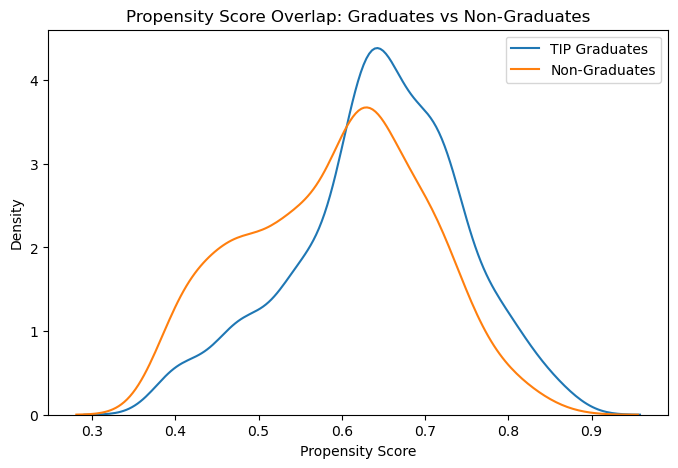


Propensity score summary by treatment:
           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          434.0  0.593052  0.106704  0.376098  0.508144  0.606025  0.668704   
1          720.0  0.642458  0.101561  0.372519  0.585045  0.646730  0.713532   

                max  
treatment            
0          0.860476  
1          0.876258  


In [608]:
# 3. Estimate propensity scores and inspect overlap

# Propensity score model uses pre-treatment covariates only
psm_covariates = X_values.drop(columns=['treatment']).copy()

psm_model = LogisticRegression(max_iter=2000, random_state=42)
psm_model.fit(psm_covariates, analysis_df['treatment'])

psm_diagnostics = psm_covariates.copy()
psm_diagnostics['pscore'] = psm_model.predict_proba(psm_covariates)[:, 1]
psm_diagnostics['treatment'] = analysis_df['treatment'].astype(int).values

plt.figure(figsize=(8, 5))
sns.kdeplot(
    psm_diagnostics.loc[psm_diagnostics['treatment'] == 1, 'pscore'],
    label='TIP Graduates'
)
sns.kdeplot(
    psm_diagnostics.loc[psm_diagnostics['treatment'] == 0, 'pscore'],
    label='Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap: Graduates vs Non-Graduates')
plt.legend()
plt.show()

print("\nPropensity score summary by treatment:")
print(psm_diagnostics.groupby('treatment')['pscore'].describe())

In [609]:
# 4. Run naive logistic regression for employment

X_logit = sm.add_constant(X_values.copy())

logit_has_employment = sm.Logit(Y_has_employment, X_logit).fit()
logit_has_employment.summary()



         Current function value: 0.388331
         Iterations: 35


C:\Users\sarah\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     employment_outcome   No. Observations:                 1154
Model:                          Logit   Df Residuals:                     1137
Method:                           MLE   Df Model:                           16
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.4209
Time:                        15:43:59   Log-Likelihood:                -448.13
converged:                      False   LL-Null:                       -773.90
Covariance Type:            nonrobust   LLR p-value:                2.621e-128
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.4345      0.374      1.163      0.245      -0.298       1.167
treatment                      0.1805      0.179      1.007      0.314      -0.171       0.532
year_TIP                       1.7003      0.172      9.867      0.000       1.363       2.038
any_sentence_before_start      0.0704      0.235      0.300      0.764      -0.390       0.530
any_arrest_before_start        0.1833      0.268      0.685      0.494      -0.341       0.708
job_right_before_tip           1.5936      0.235      6.796      0.000       1.134       2.053
num_sentences_before_start    -0.1403      0.109     -1.283      0.199      -0.354       0.074
num_arrests_before_start      -0.0135      0.113     -0.120      0.905      -0.234       0.207
earnings_2yr_preTIP            0.3258      0.193      1.690      0.091      -0.052       0.704
cohort_2022_1                 -2.3639      0.334     -7.072      0.000      -3.019      -1.709
age_band_35+                  -0.1529      0.236     -0.649      0.517      -0.615       0.309
age_band_<=24                  0.1518      0.206      0.737      0.461      -0.252       0.555
age_band_Unknown              -0.1400      0.312     -0.449      0.653      -0.751       0.471
race_Unknown                 -21.3226   1.58e+04     -0.001      0.999   -3.09e+04    3.09e+04
race_White                    -0.0876      0.270     -0.324      0.746      -0.617       0.442
gender_Male                    0.2436      0.307      0.794      0.427      -0.358       0.845
gender_Unknown                -5.8935   8.45e+04  -6.97e-05      1.000   -1.66e+05    1.66e+05
==============================================================================================
"""

In [610]:
# 5. Display coefficients and sample counts

logit_has_employment_summary = (
    logit_has_employment.summary2().tables[1].reset_index()
)

print(logit_has_employment_summary[['index', 'Coef.', 'P>|z|']])

print("\nTreatment counts:")
print(analysis_df['treatment'].value_counts(dropna=False))

print("\nStatus counts:")
print(analysis_df['Status'].value_counts(dropna=False))

                         index      Coef.         P>|z|
0                        const   0.434475  2.448567e-01
1                    treatment   0.180534  3.139592e-01
2                     year_TIP   1.700323  5.767778e-23
3    any_sentence_before_start   0.070350  7.644013e-01
4      any_arrest_before_start   0.183311  4.935346e-01
5         job_right_before_tip   1.593582  1.078927e-11
6   num_sentences_before_start  -0.140254  1.994208e-01
7     num_arrests_before_start  -0.013481  9.046595e-01
8          earnings_2yr_preTIP   0.325774  9.097010e-02
9                cohort_2022_1  -2.363910  1.531886e-12
10                age_band_35+  -0.152889  5.165602e-01
11               age_band_<=24   0.151774  4.610923e-01
12            age_band_Unknown  -0.139964  6.532219e-01
13                race_Unknown -21.322592  9.989214e-01
14                  race_White  -0.087567  7.457830e-01
15                 gender_Male   0.243628  4.271095e-01
16              gender_Unknown  -5.893525  9.999

# Matching

In [611]:
matching_df = grad_non_grad.copy()

# Keep needed variables
matching_df = matching_df[
    [
        'tip_id',
        'Status',
        'treatment',
        'StartDate',
        'year_TIP',
        'cohort_2022',
        'Age_at_start',
        'age_band',
        'race',
        'gender',
        'census_tract',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_1yr_preTIP',
        'earnings_2yr_preTIP',
        'job_right_before_tip',
        'employment_outcome',
        'earnings_outcome',
        'offense_outcome',
        'arrest_outcome'
        
    ]
].copy()

# Clean matching variables
matching_df = matching_df.dropna(subset=['treatment', 'cohort_2022', 'age_band', 'race', 'gender']).copy()

matching_df['treatment'] = matching_df['treatment'].astype(int)
matching_df['cohort_2022'] = matching_df['cohort_2022'].astype(int)
matching_df['age_band'] = matching_df['age_band'].astype(str)
matching_df['race'] = matching_df['race'].astype(str)
matching_df['gender'] = matching_df['gender'].astype(str)

print("matching_df shape:", matching_df.shape)
print("\nTreatment counts:")
print(matching_df['treatment'].value_counts(dropna=False))

print("\nExact-match strata counts:")
print(
    matching_df.groupby(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
    .size()
    .reset_index(name='n')
    .sort_values(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
)

matching_df shape: (1047, 24)

Treatment counts:
treatment
1    646
0    401
Name: count, dtype: int64

Exact-match strata counts:
    cohort_2022     race   gender age_band  treatment    n
0             0    Black   Female    25-34          0    5
1             0    Black   Female    25-34          1   11
2             0    Black   Female      35+          0    4
3             0    Black   Female      35+          1    5
4             0    Black   Female     <=24          0    9
5             0    Black   Female     <=24          1    7
6             0    Black     Male    25-34          0  112
7             0    Black     Male    25-34          1  182
8             0    Black     Male      35+          0   34
9             0    Black     Male      35+          1   85
10            0    Black     Male     <=24          0  107
11            0    Black     Male     <=24          1   84
12            0  Unknown     Male    25-34          0    1
13            0  Unknown     Male    25-34 

In [612]:
psm_df = matching_df.copy()

# Covariates for propensity score model
# psm_covariates = psm_df[
    # [
        # 'year_TIP',
        # 'any_sentence_before_start',
        # 'num_sentences_before_start',
        # 'max_ogs_before_start',
        # 'any_high_ogs_before_start',
        # 'any_arrest_before_start',
        # 'num_arrests_before_start',
        # 'earnings_year_prior',
        # 'earnings_two_years_prior',
        # 'job_right_before_tip',
        # 'conviction_record_count_y'
    # ]
# ].copy()

psm_covariates = psm_df[
    [
        'year_TIP',
        'num_sentences_before_start',
        'num_arrests_before_start',
        'any_high_ogs_before_start',
      #  'earnings_1yr_preTIP',
        'earnings_2yr_preTIP',
        'job_right_before_tip'
    ]
].copy()



# Standardize continuous variables
continuous_vars = [
    'year_TIP',
    'num_sentences_before_start',
    'num_arrests_before_start',
    #'earnings_1yr_preTIP',
    'earnings_2yr_preTIP'
]

scaler = StandardScaler()
psm_covariates[continuous_vars] = scaler.fit_transform(psm_covariates[continuous_vars])

# Fit logistic regression for propensity score
psm_model = LogisticRegression(max_iter=2000, random_state=42)
psm_model.fit(psm_covariates, psm_df['treatment'])

psm_df['pscore'] = psm_model.predict_proba(psm_covariates)[:, 1]

print(psm_df['pscore'].describe())

print("\nPropensity score by treatment:")
print(psm_df.groupby('treatment')['pscore'].describe())

count    1047.000000
mean        0.617000
std         0.053469
min         0.502690
25%         0.580212
50%         0.615305
75%         0.645048
max         0.829552
Name: pscore, dtype: float64

Propensity score by treatment:
           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          401.0  0.609425  0.051177  0.502690  0.572736  0.604841  0.637576   
1          646.0  0.621702  0.054353  0.504956  0.585282  0.615905  0.655909   

                max  
treatment            
0          0.735194  
1          0.829552  


In [613]:
def nearest_neighbor_match_within_strata(
    df,
    exact_vars,
    treatment_col='treatment',
    id_col='tip_id',
    pscore_col='pscore',
    caliper=0.20
):
    """
    1:1 nearest-neighbor matching without replacement
    within exact-match strata, using propensity score distance.

    caliper is applied on the absolute difference in propensity score.
    """
    matched_rows = []
    matched_control_ids = set()

    treated_df = df[df[treatment_col] == 1].copy()
    control_df = df[df[treatment_col] == 0].copy()

    treated_df = treated_df.sort_values(pscore_col).reset_index(drop=True)

    pair_id = 1

    for _, treated_row in treated_df.iterrows():
        strata_mask = np.ones(len(control_df), dtype=bool)

        for var in exact_vars:
            strata_mask &= (control_df[var] == treated_row[var])

        eligible_controls = control_df.loc[strata_mask].copy()

        if len(eligible_controls) == 0:
            continue

        eligible_controls = eligible_controls[
            ~eligible_controls[id_col].isin(matched_control_ids)
        ].copy()

        if len(eligible_controls) == 0:
            continue

        eligible_controls['pscore_diff'] = np.abs(
            eligible_controls[pscore_col] - treated_row[pscore_col]
        )

        eligible_controls = eligible_controls[
            eligible_controls['pscore_diff'] <= caliper
        ].copy()

        if len(eligible_controls) == 0:
            continue

        best_control = eligible_controls.sort_values('pscore_diff').iloc[0]

        treated_out = treated_row.to_dict()
        treated_out['match_pair_id'] = pair_id
        treated_out['match_role'] = 'treated'
        treated_out['matched_to_id'] = best_control[id_col]
        treated_out['match_pscore_diff'] = abs(treated_row[pscore_col] - best_control[pscore_col])

        control_out = best_control.to_dict()
        control_out['match_pair_id'] = pair_id
        control_out['match_role'] = 'control'
        control_out['matched_to_id'] = treated_row[id_col]
        control_out['match_pscore_diff'] = abs(treated_row[pscore_col] - best_control[pscore_col])

        matched_rows.append(treated_out)
        matched_rows.append(control_out)

        matched_control_ids.add(best_control[id_col])
        pair_id += 1

    matched_df = pd.DataFrame(matched_rows)
    return matched_df


exact_match_vars = ['cohort_2022', 'race', 'gender', 'age_band']

matched_grad_non_grad = nearest_neighbor_match_within_strata(
    df=psm_df,
    exact_vars=exact_match_vars,
    treatment_col='treatment',
    id_col='tip_id',
    pscore_col='pscore',
    caliper=0.20
)

print("matched_grad_non_grad shape:", matched_grad_non_grad.shape)
print("\nMatched pair count:", matched_grad_non_grad['match_pair_id'].nunique())

print("\nMatched treatment counts:")
print(matched_grad_non_grad['treatment'].value_counts(dropna=False))

matched_grad_non_grad shape: (742, 30)

Matched pair count: 371

Matched treatment counts:
treatment
1    371
0    371
Name: count, dtype: int64


In [614]:
print("Matched status counts:")
print(matched_grad_non_grad['Status'].value_counts(dropna=False))

print("\nMatched exact strata check:")
print(
    matched_grad_non_grad.groupby(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
    .size()
    .reset_index(name='n')
    .sort_values(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
)

print("\nAverage propensity score difference within matched pairs:")
print(matched_grad_non_grad[['match_pair_id', 'match_pscore_diff']].drop_duplicates()['match_pscore_diff'].describe())

Matched status counts:
Status
Graduated        371
Non Graduated    371
Name: count, dtype: int64

Matched exact strata check:
    cohort_2022     race   gender age_band  treatment    n
0             0    Black   Female    25-34          0    5
1             0    Black   Female    25-34          1    5
2             0    Black   Female      35+          0    4
3             0    Black   Female      35+          1    4
4             0    Black   Female     <=24          0    7
5             0    Black   Female     <=24          1    7
6             0    Black     Male    25-34          0  112
7             0    Black     Male    25-34          1  112
8             0    Black     Male      35+          0   34
9             0    Black     Male      35+          1   34
10            0    Black     Male     <=24          0   84
11            0    Black     Male     <=24          1   84
12            0  Unknown     Male    25-34          0    1
13            0  Unknown     Male    25-34     

In [615]:
treated_pairs = matched_grad_non_grad[
    matched_grad_non_grad['match_role'] == 'treated'
][
    ['match_pair_id', 'tip_id', 'pscore', 'cohort_2022', 'race', 'gender', 'age_band', 'match_pscore_diff']
].rename(columns={
    'tip_id': 'treated_tip_id',
    'pscore': 'treated_pscore'
})

control_pairs = matched_grad_non_grad[
    matched_grad_non_grad['match_role'] == 'control'
][
    ['match_pair_id', 'tip_id', 'pscore']
].rename(columns={
    'tip_id': 'control_tip_id',
    'pscore': 'control_pscore'
})

matched_pair_summary = treated_pairs.merge(control_pairs, on='match_pair_id', how='inner')

matched_pair_summary.head(20)



,match_pair_id,treated_tip_id,treated_pscore,cohort_2022,race,gender,age_band,match_pscore_diff,control_tip_id,control_pscore
0,1,767,0.504956,0,Black,Male,25-34,0.002266,10,0.502690
1,2,699,0.504956,0,Black,Male,25-34,0.007519,707,0.512475
2,3,812,0.504956,0,Black,Male,25-34,0.007519,739,0.512475
3,4,737,0.505693,0,Black,Male,35+,0.028972,882,0.534665
4,5,585,0.511140,0,Black,Male,35+,0.023525,851,0.534665
5,6,811,0.513492,0,Black,Male,35+,0.022364,760,0.535856
6,7,97,0.518324,0,Black,Male,25-34,0.005853,130,0.524177
7,8,663,0.518333,0,White,Male,35+,0.043853,925,0.562186
8,9,605,0.519069,0,Black,Male,25-34,0.005108,121,0.524177
9,10,672,0.519069,0,Black,Male,25-34,0.005108,49,0.524177


In [616]:
matched_grad_non_grad = matched_grad_non_grad.sort_values(
    ['match_pair_id', 'match_role']
).reset_index(drop=True)

print("Final matched analysis file shape:", matched_grad_non_grad.shape)

matched_grad_non_grad.head()



Final matched analysis file shape: (742, 30)


,tip_id,Status,treatment,StartDate,year_TIP,cohort_2022,Age_at_start,age_band,race,gender,...,employment_outcome,earnings_outcome,offense_outcome,arrest_outcome,pscore,match_pair_id,match_role,matched_to_id,match_pscore_diff,pscore_diff
0,10,Non Graduated,0,2010-07-09,2010,0,30.425154,25-34,Black,Male,...,0,0.000000,0,0,0.502690,1,control,767,0.002266,0.002266
1,767,Graduated,1,2018-05-07,2018,0,28.385509,25-34,Black,Male,...,0,0.000000,0,0,0.504956,1,treated,10,0.002266,NaN
2,707,Non Graduated,0,2018-01-15,2018,0,28.508544,25-34,Black,Male,...,1,15066.561904,1,1,0.512475,2,control,699,0.007519,0.007519
3,699,Graduated,1,2018-01-08,2018,0,27.056733,25-34,Black,Male,...,1,19821.986309,0,1,0.504956,2,treated,707,0.007519,NaN
4,739,Non Graduated,0,2018-03-12,2018,0,25.416268,25-34,Black,Male,...,1,5718.395448,0,0,0.512475,3,control,812,0.007519,0.007519


# Matched Sample Diagnostics and Preliminary Outcome Comparisons

Now that we have constructed the matched graduate vs. non-graduate sample, the next step is to evaluate whether the matched sample is sufficiently balanced and to summarize outcome differences before running formal matched regressions.

This section has two goals.

First, we examine **matched sample diagnostics**. We compare the treatment and control groups on key pre-TIP covariates and compute standardized mean differences (SMDs). This helps us assess whether the matching procedure improved comparability between graduates and non-graduates.

Second, we present **simple matched outcome comparisons**. For the matched sample, we compare average employment, earnings, offense, and arrest outcomes between graduates and non-graduates. These comparisons are descriptive and are intended to show the direction and magnitude of differences after matching.

These results are not yet the final adjusted estimates. If residual imbalance remains for some baseline variables, those variables should be controlled for in the next matched regression step.m

In [617]:
matched_analysis = matched_grad_non_grad.copy()

print("Matched sample size:", len(matched_analysis))
print("Matched pair count:", matched_analysis['match_pair_id'].nunique())

print("\nTreatment counts:")
print(matched_analysis['treatment'].value_counts(dropna=False))

print("\nStatus counts:")
print(matched_analysis['Status'].value_counts(dropna=False))

print("\nCohort by treatment:")
print(pd.crosstab(matched_analysis['cohort_2022'], matched_analysis['treatment'], margins=True))

print("\nAge band by treatment:")
print(pd.crosstab(matched_analysis['age_band'], matched_analysis['treatment'], margins=True))

print("\nRace by treatment:")
print(pd.crosstab(matched_analysis['race'], matched_analysis['treatment'], margins=True))

print("\nGender by treatment:")
print(pd.crosstab(matched_analysis['gender'], matched_analysis['treatment'], margins=True))



Matched sample size: 742
Matched pair count: 371

Treatment counts:
treatment
0    371
1    371
Name: count, dtype: int64

Status counts:
Status
Non Graduated    371
Graduated        371
Name: count, dtype: int64

Cohort by treatment:
treatment      0    1  All
cohort_2022               
0            291  291  582
1             80   80  160
All          371  371  742

Age band by treatment:
treatment    0    1  All
age_band                
25-34      164  164  328
35+         52   52  104
<=24       155  155  310
All        371  371  742

Race by treatment:
treatment    0    1  All
race                    
Black      315  315  630
Unknown     21   21   42
White       35   35   70
All        371  371  742

Gender by treatment:
treatment    0    1  All
gender                  
Female      31   31   62
Male       320  320  640
Unknown     20   20   40
All        371  371  742


In [618]:
matched_analysis.columns



Index(['tip_id', 'Status', 'treatment', 'StartDate', 'year_TIP', 'cohort_2022',
       'Age_at_start', 'age_band', 'race', 'gender', 'census_tract',
       'any_sentence_before_start', 'num_sentences_before_start',
       'max_ogs_before_start', 'any_high_ogs_before_start',
       'any_arrest_before_start', 'num_arrests_before_start',
       'earnings_1yr_preTIP', 'earnings_2yr_preTIP', 'job_right_before_tip',
       'employment_outcome', 'earnings_outcome', 'offense_outcome',
       'arrest_outcome', 'pscore', 'match_pair_id', 'match_role',
       'matched_to_id', 'match_pscore_diff', 'pscore_diff'],
      dtype='object')

In [619]:
balance_vars = [
    'year_TIP',
    'num_sentences_before_start',
    'max_ogs_before_start',
    'any_high_ogs_before_start',
    'num_arrests_before_start',
    'earnings_1yr_preTIP',
    'earnings_2yr_preTIP',
    'job_right_before_tip'
    
]

balance_table = matched_analysis.groupby('treatment')[balance_vars].mean().T
balance_table.columns = ['matched_control_mean', 'matched_treated_mean']
balance_table['difference'] = (
    balance_table['matched_treated_mean'] - balance_table['matched_control_mean']
)

balance_table

,matched_control_mean,matched_treated_mean,difference
year_TIP,2018.433962,2017.994609,-0.439353
num_sentences_before_start,2.064690,1.698113,-0.366577
max_ogs_before_start,2.552561,2.401617,-0.150943
any_high_ogs_before_start,0.253369,0.245283,-0.008086
num_arrests_before_start,1.207547,1.148248,-0.059299
earnings_1yr_preTIP,4852.875168,5587.026243,734.151075
earnings_2yr_preTIP,4027.177451,2830.961354,-1196.216097
job_right_before_tip,0.431267,0.517520,0.086253


In [620]:
def standardized_mean_diff(df, treatment_col, var):
    treated = df[df[treatment_col] == 1][var].dropna()
    control = df[df[treatment_col] == 0][var].dropna()

    mean_t = treated.mean()
    mean_c = control.mean()

    var_t = treated.var()
    var_c = control.var()

    pooled_sd = np.sqrt((var_t + var_c) / 2)

    if pooled_sd == 0:
        return 0

    return (mean_t - mean_c) / pooled_sd

smd_results = []
for var in balance_vars:
    smd_results.append({
        'variable': var,
        'SMD': standardized_mean_diff(matched_analysis, 'treatment', var)
    })

smd_table = pd.DataFrame(smd_results).sort_values('SMD', key=lambda x: x.abs(), ascending=False)
smd_table

,variable,SMD
7,job_right_before_tip,0.173147
6,earnings_2yr_preTIP,-0.154076
0,year_TIP,-0.123953
1,num_sentences_before_start,-0.101635
5,earnings_1yr_preTIP,0.073877
2,max_ogs_before_start,-0.041472
4,num_arrests_before_start,-0.018783
3,any_high_ogs_before_start,-0.018667


Matched pair propensity-score difference summary:
count    371.000000
mean       0.024752
std        0.028502
min        0.000000
25%        0.003107
50%        0.015095
75%        0.033608
max        0.145371
Name: match_pscore_diff, dtype: float64


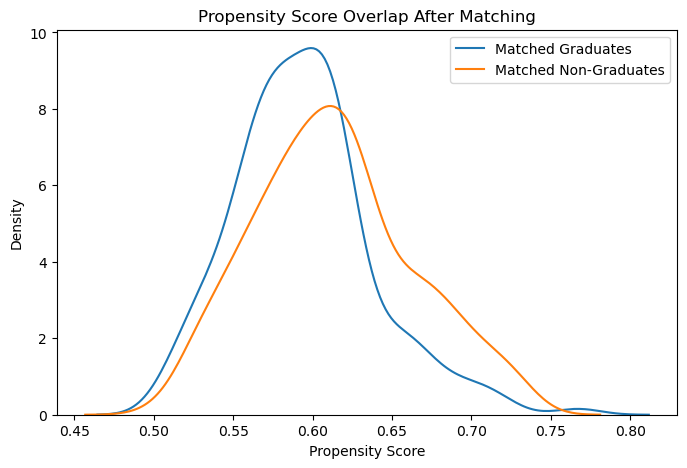

In [621]:


print("Matched pair propensity-score difference summary:")
print(
    matched_analysis[['match_pair_id', 'match_pscore_diff']]
    .drop_duplicates()['match_pscore_diff']
    .describe()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(
    matched_analysis.loc[matched_analysis['treatment'] == 1, 'pscore'],
    label='Matched Graduates'
)
sns.kdeplot(
    matched_analysis.loc[matched_analysis['treatment'] == 0, 'pscore'],
    label='Matched Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap After Matching')
plt.legend()
plt.show()



In [622]:
outcome_vars = [
    'employment_outcome',
    'earnings_outcome',
    'offense_outcome',
    'arrest_outcome'
]

matched_outcome_table = matched_analysis.groupby('treatment')[outcome_vars].mean().T
matched_outcome_table.columns = ['matched_control_mean', 'matched_treated_mean']
matched_outcome_table['difference'] = (
    matched_outcome_table['matched_treated_mean'] - matched_outcome_table['matched_control_mean']
)

matched_outcome_table

,matched_control_mean,matched_treated_mean,difference
employment_outcome,0.611860,0.606469,-0.005391
earnings_outcome,10217.946049,10452.340149,234.394100
offense_outcome,0.072776,0.088949,0.016173
arrest_outcome,0.110512,0.107817,-0.002695


In [623]:
##tip_demos = tip_demos.set_index('tip_id').to_dict(orient='index')
all_tip_data_dict = all_tip_data.set_index('tip_id').to_dict(orient='index')

tip_sentencing = tip_sentencing.dropna(subset=['DOS'])
tip_sentencing['year'] = tip_sentencing['DOS'].dt.year.astype(int)

all_tip_data['year'] = all_tip_data['StartDate'].dt.year.astype(int)

In [624]:
def participated_tip(tip_id, year):
    if len(all_tip_data[(all_tip_data['tip_id'] == tip_id) & (all_tip_data['year'] <= year)]) > 0:
        return 1
    else:
        return 0
    
def graduated_tip(tip_id, year):
    if len(all_tip_data[(all_tip_data['tip_id'] == tip_id) & (all_tip_data['year'] <= year) & (all_tip_data['Status'] == 'Graduated')]) > 0:
        return 1
    else:
        return 0

def employed_full_year(tip_id, year):
    earnings = tip_earnings[(tip_earnings['tip_id'] == tip_id) & (tip_earnings['year'] == year)]
    if len(earnings) == 0:
        return 0
    else:
        if earnings['year_quarter_dt'].nunique() == 4:
            return 1
        else:
            return 0
        
def employed_partial_year(tip_id, year):
    earnings = tip_earnings[(tip_earnings['tip_id'] == tip_id) & (tip_earnings['year'] == year)]
    if len(earnings) == 0:
        return 0
    else:
        if earnings['year_quarter_dt'].nunique() > 0:
            return 1
        else:
            return 0
        
def earnings_full_year(tip_id, year):
    earnings = tip_earnings[(tip_earnings['tip_id'] == tip_id) & (tip_earnings['year'] == year)]
    return earnings['adjusted_earnings'].sum() if len(earnings) > 0 else 0

def offense_count_full_year(tip_id, year):
    offenses = tip_sentencing[(tip_sentencing['tip_id'] == tip_id) & (tip_sentencing['year'] == year)]
    if len(offenses) > 0:
        return len(offenses)
    else:
        return 0
    
def has_offense_full_year(tip_id, year):
    offenses = tip_sentencing[(tip_sentencing['tip_id'] == tip_id) & (tip_sentencing['year'] == year)]
    if len(offenses) > 0:
        return 1
    else:
        return 0

In [625]:
panel_df = []

for tip_id in matched_grad_non_grad.tip_id.unique():
    for year in range(2017, 2025):
        panel_df.append({
            'tip_id': tip_id,
            'year': year,
            'StartDate' : all_tip_data_dict[tip_id]['StartDate'] if tip_id in all_tip_data_dict else 'Unknown',
            'Status' : all_tip_data_dict[tip_id]['Status'] if tip_id in all_tip_data_dict else 'Unknown',
            'cohort_2022' : all_tip_data_dict[tip_id]['cohort_2022'] if tip_id in all_tip_data_dict else 'Unknown',
            'race': tip_demos[tip_id]['race'] if tip_id in tip_demos else 'Unknown',
            'gender': tip_demos[tip_id]['gender'] if tip_id in tip_demos else 'Unknown',
            'census_tract': int(tip_demos[tip_id]['census_tract']) if tip_id in tip_demos and not pd.isnull(tip_demos[tip_id]['census_tract']) else "Unknown",
            'participated_tip': participated_tip(tip_id, year),
            'graduated_tip': graduated_tip(tip_id, year),
            'employed_full_year': employed_full_year(tip_id, year),
            'employed_partial_year': employed_partial_year(tip_id, year),
            'earnings_full_year': earnings_full_year(tip_id, year),
            'offense_count_year': offense_count_full_year(tip_id, year),
            'has_offense_year': has_offense_full_year(tip_id, year)
        })
panel_df = pd.DataFrame(panel_df)



In [626]:
panel_df.head()

,tip_id,year,StartDate,Status,cohort_2022,race,gender,census_tract,participated_tip,graduated_tip,employed_full_year,employed_partial_year,earnings_full_year,offense_count_year,has_offense_year
0,10,2017,2010-07-09,Non Graduated,0.0,Unknown,Unknown,Unknown,1,0,1,1,186.657964,0,0
1,10,2018,2010-07-09,Non Graduated,0.0,Unknown,Unknown,Unknown,1,0,1,1,43.645538,0,0
2,10,2019,2010-07-09,Non Graduated,0.0,Unknown,Unknown,Unknown,1,0,1,1,315.259520,0,0
3,10,2020,2010-07-09,Non Graduated,0.0,Unknown,Unknown,Unknown,1,0,1,1,140.611929,0,0
4,10,2021,2010-07-09,Non Graduated,0.0,Unknown,Unknown,Unknown,1,0,1,1,5267.583188,0,0


# Fixed Effects Model

We will create a fixed effects model that estimates the impact of Graduating TIP on the earnings of TIP Participants:

$$
\text{Earnings}_{it} = \alpha_i + \gamma_t + \beta * \text{Graduated\_TIP}_{it} + \delta * \text{Has\_Offense}_{it} + + \epsilon_{it}
$$

Where:
- $\text{Earnings}_{it}$ is the earnings of individual $i$ at time $t$.
- $\alpha_i$ is the individual fixed effect.
- $\gamma_t$ is the time fixed effect.
- $\text{Graduated\_TIP}_{it}$ is a binary variable indicating whether individual $i$ graduated from TIP by time $t$.
- $\text{Has\_Offense}_{it}$ is a binary variable indicating whether individual $i$ has an offense at time $t$.
- $\beta$ is the coefficient for the Graduated_TIP variable.
- $\delta$ is the coefficient for the Has_Offense variable.
- $\epsilon_{it}$ is the error term.

We will create a separate fixed effects model by cohort so that we can include entity effects, which we would not be able to include if we tried to add cohort_2022 to this model.

In [627]:
##For pre-2022 cohort
pre_2022_panel = panel_df[panel_df["cohort_2022"] == 0].copy()
post_2022_panel = panel_df[panel_df["cohort_2022"] == 1].copy()

pre_fe_data = pre_2022_panel[['tip_id', 'year', 'race', 'gender', 'census_tract', 'graduated_tip', 'has_offense_year']].copy()
pre_fe_data['log_earnings'] = np.log(pre_2022_panel['earnings_full_year'] + 1)
pre_fe_data = pre_fe_data.set_index(['tip_id', 'year'])

pre_model_fe = PanelOLS.from_formula(
    formula="""
    log_earnings ~ 1 + graduated_tip + has_offense_year + EntityEffects + TimeEffects
    """,
    data=pre_fe_data
)

##For post-2022 cohort
post_fe_data = post_2022_panel[['tip_id', 'year', 'race', 'gender', 'census_tract', 'graduated_tip', 'has_offense_year']].copy()
post_fe_data['log_earnings'] = np.log(post_2022_panel['earnings_full_year'] + 1)
post_fe_data = post_fe_data.set_index(['tip_id', 'year'])

post_model_fe = PanelOLS.from_formula(
    formula="""
    log_earnings ~ 1 + graduated_tip + has_offense_year + EntityEffects + TimeEffects
    """,
    data=post_fe_data
)


In [628]:
pre_2022_results = pre_model_fe.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
print(pre_2022_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           log_earnings   R-squared:                        0.0038
Estimator:                   PanelOLS   R-squared (Between):             -0.0129
No. Observations:                4656   R-squared (Within):               0.0092
Date:                Sun, Mar 29 2026   R-squared (Overall):             -0.0022
Time:                        15:45:05   Log-likelihood                -1.193e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      7.6676
Entities:                         582   P-value                           0.0005
Avg Obs:                       8.0000   Distribution:                  F(2,4065)
Min Obs:                       8.0000                                           
Max Obs:                       8.0000   F-statistic (robust):             4.7952
                            

In [629]:
post_2022_results = post_model_fe.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
print(post_2022_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           log_earnings   R-squared:                        0.0008
Estimator:                   PanelOLS   R-squared (Between):              0.0048
No. Observations:                1280   R-squared (Within):               0.0121
Date:                Sun, Mar 29 2026   R-squared (Overall):              0.0089
Time:                        15:45:08   Log-likelihood                   -3210.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.4617
Entities:                         160   P-value                           0.6303
Avg Obs:                       8.0000   Distribution:                  F(2,1111)
Min Obs:                       8.0000                                           
Max Obs:                       8.0000   F-statistic (robust):             0.3062
                            

C:\Users\sarah\anaconda3\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")


In [630]:
100 * (np.exp(pre_2022_results.params['graduated_tip']) - 1)

np.float64(141.07197972180617)

In [631]:
100 * (np.exp(post_2022_results.params['graduated_tip']) - 1)

np.float64(39.52862989170125)

In [632]:
100 * (np.exp(pre_2022_results.params['has_offense_year']) - 1)

np.float64(-32.20253697146467)

In [633]:
100 * (np.exp(post_2022_results.params['has_offense_year']) - 1)

np.float64(-13.271083236517923)

- For the **pre-2022** cohort, **graduating TIP** is associated with roughly an **141% increase in annual earnings** in a given year, compared to non-graduates and holding entity and time fixed effects constant. This is a **significant effect** (p<.05).
- For the **post-2022 cohort**, **graduating TIP** is associated with roughly an **40% increase** in annual earnings in a given year, compared to non-graduates and holding entity and time fixed effects constant. This is **not significantly different** (p > .05)

- For the **pre-2022 cohort**, having **an offense** is associated with roughly a **32% decrease** in annual earnings in a given year, compared to non-offenders and holding entity and time fixed effects constant. This is **approaching significance** (p ~ .05).
- For the **pre-2022 cohort**, having **an offense** is associated with roughly a **13% decrease** in annual earnings in a given year, compared to non-offenders and holding entity and time fixed effects constant. This is **not signficantly different** (p > .05)


# Logistic Panel Regression using GEE

We will create a logistic panel regression model using Generalized Estimating Equations (GEE) to estimate the impact of Graduating TIP on the likelihood of having a job:

$$
Y_{it} = {0 \text{ if no job} \atop 1 \text{ if has job}}
$$

Where:

$$
\text{logit}\!\Bigl(\mathbb{E}[Y_{it} | X_{it}]\Bigr) = X_{it}\beta
$$

Where:
- $Y_{it}$ is the binary outcome variable indicating whether individual $i$ has a job at time $t$.
- $X_{it}$ is a vector of independent variables including the Graduated_TIP variable.
- $\beta$ is the vector of coefficients to be estimated.

In [634]:
gee_data = panel_df[['tip_id', 'year', 'race', 'gender', 'StartDate', 'census_tract', 'cohort_2022', 'graduated_tip', 'has_offense_year', 'employed_partial_year']].copy()

gee_data = pd.get_dummies(gee_data, columns=['year'], drop_first=True)

y = gee_data['employed_partial_year']
year_dummies = [col for col in gee_data.columns if 'year_' in col]
X = gee_data[['graduated_tip', 'has_offense_year', 'cohort_2022'] + year_dummies]
X[year_dummies] = X[year_dummies].astype(int)
X['gradXcohort'] = X['graduated_tip'] * X['cohort_2022']

groups = gee_data['tip_id']
cov_struct = Exchangeable()

model_gee = GEE(
    endog=y,
    exog=X,
    groups=groups,
    cov_struct=cov_struct,
    family=Binomial()
)

results_gee = model_gee.fit()

C:\Users\sarah\AppData\Local\Temp\ipykernel_26960\294522434.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[year_dummies] = X[year_dummies].astype(int)
C:\Users\sarah\AppData\Local\Temp\ipykernel_26960\294522434.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['gradXcohort'] = X['graduated_tip'] * X['cohort_2022']


In [635]:
results_gee.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                               
====================================================================================
Dep. Variable:        employed_partial_year   No. Observations:                 5936
Model:                                  GEE   No. clusters:                      742
Method:                         Generalized   Min. cluster size:                   8
                       Estimating Equations   Max. cluster size:                   8
Family:                            Binomial   Mean cluster size:                 8.0
Dependence structure:          Exchangeable   Num. iterations:                    22
Date:                      Sun, 29 Mar 2026   Scale:                           1.000
Covariance type:                     robust   Time:                         15:46:24
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
graduated_tip        0.2682      0.081      3.303      0.001       0.109       0.427
has_offense_year     0.2064      0.023      8.806      0.000       0.160       0.252
cohort_2022          1.3010      0.229      5.683      0.000       0.852       1.750
year_2018            0.2683      0.024     11.098      0.000       0.221       0.316
year_2019            0.3004      0.037      8.163      0.000       0.228       0.373
year_2020            0.4071      0.043      9.411      0.000       0.322       0.492
year_2021            0.5706      0.047     12.157      0.000       0.479       0.663
year_2022            0.6629      0.048     13.676      0.000       0.568       0.758
year_2023            0.6676      0.049     13.630      0.000       0.572       0.764
year_2024            0.6585      0.050     13.250      0.000       0.561       0.756
gradXcohort         -0.3090      0.137     -2.255      0.024      -0.578      -0.040
==============================================================================
Skew:                         -2.2468   Kurtosis:                       4.0259
Centered skew:                -1.3703   Centered kurtosis:             10.3821
==============================================================================
"""

In [636]:
print(np.exp(results_gee.params['graduated_tip']))
print(np.exp(results_gee.params['has_offense_year']))
print(np.exp(results_gee.params['cohort_2022']))
print(np.exp((results_gee.params['graduated_tip'] + results_gee.params['gradXcohort'])))


1.3075747860702136
1.2292576877218602
3.6730286290994965
0.9599750405932684


- In the **pre-2022 cohort**, there is about a **31% increase** in the odds of employment for those who graduated from TIP compared to those who did not, and this is **significant** (p < .05).
- In the **post-2022 cohort** there is a **very slight decrease** in the odds of employment for those who graduated from TIP compared to those who did not, and this is **significant** (p < .05).
- Across both cohorts, there is **22% increase** in the odds of employment for those who have an offense compared to those who do not, and this is **significant**.
- In the **post-2022 cohort**, there is a **24% increase** in the odds of employment for those who have an offense compared to those who do not, and this is statistically significant.

In [637]:
gee_data = panel_df[['tip_id', 'year', 'race', 'gender', 'StartDate', 'census_tract', 'cohort_2022', 'graduated_tip', 'has_offense_year', 'employed_partial_year']].copy()

#get year from start date
gee_data['entry_year'] = gee_data['StartDate'].dt.year

#create post program indicator
gee_data['post_program'] = (gee_data['year'] >= gee_data['entry_year']).astype(int)

# Create year dummies
gee_data = pd.get_dummies(gee_data, columns=['year'], drop_first=True)

# Outcome
y = gee_data['employed_partial_year']

# Predictor columns
year_dummies = [col for col in gee_data.columns if col.startswith('year_')]

# Interactions: graduated_tip * post_program * cohort_2022
gee_data['gradXpost'] = gee_data['graduated_tip'] * gee_data['post_program']
gee_data['postXcohort'] = gee_data['post_program'] * gee_data['cohort_2022']
gee_data['gradXpostXcohort'] = gee_data['graduated_tip'] * gee_data['post_program'] * gee_data['cohort_2022']

X = gee_data[['graduated_tip', 'post_program', 'cohort_2022', 
              'gradXpost', 'postXcohort', 'gradXpostXcohort'] + year_dummies]

# Ensure correct data type
X = X.astype(float)

# Groups for repeated measures
groups = gee_data['tip_id']

# Fit GEE
cov_struct = Exchangeable()
gee_model = GEE(endog=y, exog=X, groups=groups, cov_struct=cov_struct, family=Binomial())
gee_results = gee_model.fit()

print(gee_results.summary())

                               GEE Regression Results                               
Dep. Variable:        employed_partial_year   No. Observations:                 5936
Model:                                  GEE   No. clusters:                      742
Method:                         Generalized   Min. cluster size:                   8
                       Estimating Equations   Max. cluster size:                   8
Family:                            Binomial   Mean cluster size:                 8.0
Dependence structure:          Exchangeable   Num. iterations:                    22
Date:                      Sun, 29 Mar 2026   Scale:                           1.000
Covariance type:                     robust   Time:                         15:46:44
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
graduated_tip        0.0692      0.050      1.373      0.170     

In [638]:
print(np.exp(gee_results.params['graduated_tip']))
print(np.exp(gee_results.params['post_program']))
print(np.exp(gee_results.params['cohort_2022']))
print(np.exp(gee_results.params['gradXpost']))
print(np.exp(gee_results.params['postXcohort']))
print(np.exp(gee_results.params['gradXpostXcohort']))


1.0716344400701097
1.1838322584382972
4.085179934639139
1.0643175637350166
1.2497262527839164
0.6065214799846729


- In the **pre-2022 cohort** there is a **positive effect** on the odds of employment post-program for those who graduated from TIP compared to those who did not, but it is **not significantly different** (p > .05)
- In the **post-2022 cohort** there is a **signifiantly smaller TIP effect** on the odds of employment post-program.